In [21]:
import numpy as np
import time

# Creamos dos arrays grandes
a = np.random.rand(1000000)
b = np.random.rand(1000000)
c = np.empty(1000000)

start = time.time()
for i in range(1000000):
    c[i] = a[i] + b[i]
end = time.time()

print("Tiempo con bucle for:", end - start, "segundos")

Tiempo con bucle for: 0.36141490936279297 segundos


In [22]:
# SMID

# SMID

In [23]:

start = time.time()
c = a + b  # Esta operación se realiza en paralelo internamente
end = time.time()

print("Tiempo con NumPy vectorizado:", end - start, "segundos")

Tiempo con NumPy vectorizado: 0.0014104843139648438 segundos


In [24]:
# Tratamiento de datos 

# Tratamiento de Datos

## Primer paso

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Creamos un conjunto de datos simple con algunos problemas comunes
data = {
    'ip_origen': ['192.168.1.1', '10.0.0.1', None, '172.16.0.1', '192.168.1.1'],
    'puerto': [80, 443, 22, np.nan, 80], #valor nulo de numpy
    'protocolo': ['HTTP', 'https', 'SSH', 'http', None],
    'intentos_acceso': [5, 10, None, 7, 5],
    'timestamp': ['2023-01-01', '2023-01-01', '2023-01-02', '2023-01-03', '2023-01-01'],
    'exito': [False, True, False, True, False]
}

# Creamos un DataFrame de pandas
df = pd.DataFrame(data)

print("DataFrame original:")
print(df)
print("\n")

DataFrame original:
     ip_origen  puerto protocolo  intentos_acceso   timestamp  exito
0  192.168.1.1    80.0      HTTP              5.0  2023-01-01  False
1     10.0.0.1   443.0     https             10.0  2023-01-01   True
2         None    22.0       SSH              NaN  2023-01-02  False
3   172.16.0.1     NaN      http              7.0  2023-01-03   True
4  192.168.1.1    80.0      None              5.0  2023-01-01  False




In [26]:
print("Información básica del DataFrame:")
print(df.info())
print("\n")

Información básica del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ip_origen        4 non-null      object 
 1   puerto           4 non-null      float64
 2   protocolo        4 non-null      object 
 3   intentos_acceso  4 non-null      float64
 4   timestamp        5 non-null      object 
 5   exito            5 non-null      bool   
dtypes: bool(1), float64(2), object(3)
memory usage: 337.0+ bytes
None




In [27]:
# 3. Verificamos valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\n")

Valores nulos por columna:
ip_origen          1
puerto             1
protocolo          1
intentos_acceso    1
timestamp          0
exito              0
dtype: int64




In [20]:
# 3. Verificamos valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\n")

Valores nulos por columna:
ip_origen          1
puerto             1
protocolo          1
intentos_acceso    1
timestamp          0
exito              0
dtype: int64




In [28]:
# 4. Eliminamos registros duplicados
df_sin_duplicados = df.drop_duplicates()
print("DataFrame sin registros duplicados:")
print(df_sin_duplicados)
print("\n")

DataFrame sin registros duplicados:
     ip_origen  puerto protocolo  intentos_acceso   timestamp  exito
0  192.168.1.1    80.0      HTTP              5.0  2023-01-01  False
1     10.0.0.1   443.0     https             10.0  2023-01-01   True
2         None    22.0       SSH              NaN  2023-01-02  False
3   172.16.0.1     NaN      http              7.0  2023-01-03   True
4  192.168.1.1    80.0      None              5.0  2023-01-01  False




# 5. Manejamos valores nulos
## 5.1 Para valores categóricos, rellenamos con 'DESCONOCIDO'

# 5. Manejamos valores nulos
## 5.1 Para valores categóricos, rellenamos con 'DESCONOCIDO'

In [29]:
df['ip_origen'].fillna('DESCONOCIDO', inplace=True)
df['protocolo'].fillna('DESCONOCIDO', inplace=True)

/tmp/ipykernel_5670/1520183853.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ip_origen'].fillna('DESCONOCIDO', inplace=True)
/tmp/ipykernel_5670/1520183853.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [30]:
print(df)

     ip_origen  puerto    protocolo  intentos_acceso   timestamp  exito
0  192.168.1.1    80.0         HTTP              5.0  2023-01-01  False
1     10.0.0.1   443.0        https             10.0  2023-01-01   True
2  DESCONOCIDO    22.0          SSH              NaN  2023-01-02  False
3   172.16.0.1     NaN         http              7.0  2023-01-03   True
4  192.168.1.1    80.0  DESCONOCIDO              5.0  2023-01-01  False


In [33]:
# 5.2 Para valores numéricos, rellenamos con la media
df['puerto'].fillna(df['puerto'].mean(), inplace=True)
df['intentos_acceso'].fillna(df['intentos_acceso'].mean(), inplace=True)

/tmp/ipykernel_5670/992182245.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['puerto'].fillna(df['puerto'].mean(), inplace=True)
/tmp/ipykernel_5670/992182245.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [32]:
# 6. Estandarizamos valores (convertimos todos los protocolos a mayúsculas)
df['protocolo'] = df['protocolo'].str.upper()

print("DataFrame después de estandarizar protocolos:")
print(df)
print("\n")

# 7. Creamos una nueva columna basada en cálculos
df['es_puerto_comun'] = df['puerto'].apply(lambda x: x in [80, 443, 22, 21, 25])

DataFrame después de estandarizar protocolos:
     ip_origen  puerto    protocolo  intentos_acceso   timestamp  exito
0  192.168.1.1   80.00         HTTP             5.00  2023-01-01  False
1     10.0.0.1  443.00        HTTPS            10.00  2023-01-01   True
2  DESCONOCIDO   22.00          SSH             6.75  2023-01-02  False
3   172.16.0.1  156.25         HTTP             7.00  2023-01-03   True
4  192.168.1.1   80.00  DESCONOCIDO             5.00  2023-01-01  False




In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Creamos un dataset simulando un registro de conexiones de red
data = {
    'timestamp': pd.date_range(start='2023-01-01', periods=10, freq='H'),
    'ip_origen': ['192.168.1.' + str(i) for i in range(1, 11)],
    'ip_destino': ['10.0.0.' + str(i % 3 + 1) for i in range(10)],
    'puerto': [80, 443, 22, 3389, 8080, 80, 443, 22, 8080, 3389],
    'protocolo': ['HTTP', 'HTTPS', 'SSH', 'RDP', 'HTTP', 'HTTP', 'HTTPS', 'SSH', 'HTTP', 'RDP'],
    'bytes_enviados': np.random.randint(100, 10000, 10),
    'exito_conexion': [True, True, False, True, True, True, False, False, True, True]
}

# Creamos el DataFrame
df = pd.DataFrame(data)

print("1. Explorando el DataFrame:")
print(df.head())
print("\nInformación del DataFrame:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())

# 2. Selección de datos
print("\n2. Selección de datos:")
# Seleccionar una columna (devuelve una Serie)
print("\nSelección de una columna (Serie):")
print(df['protocolo'])

# Seleccionar múltiples columnas (devuelve un DataFrame)
print("\nSelección de múltiples columnas (DataFrame):")
print(df[['ip_origen', 'protocolo', 'puerto']])

# Selección por índice con iloc
print("\nSelección por índice con iloc (primeras 2 filas, columnas 0 y 2):")
print(df.iloc[0:2, [0, 2]])

# Selección por nombre con loc
print("\nSelección por nombre con loc (filas donde protocolo es 'HTTP'):")
print(df.loc[df['protocolo'] == 'HTTP', ['timestamp', 'ip_origen', 'puerto']])

# 3. Filtrado de datos
print("\n3. Filtrado de datos:")
# Filtrar conexiones exitosas
conexiones_exitosas = df[df['exito_conexion'] == True]
print("\nConexiones exitosas:")
print(conexiones_exitosas[['timestamp', 'ip_origen', 'protocolo']])

# Filtrado múltiple (conexiones HTTP en puerto 80)
http_port80 = df[(df['protocolo'] == 'HTTP') & (df['puerto'] == 80)]
print("\nConexiones HTTP en puerto 80:")
print(http_port80)

# 4. Transformación de datos
print("\n4. Transformación de datos:")
# Añadir una nueva columna
df['hora'] = df['timestamp'].dt.hour
print("\nDataFrame con nueva columna 'hora':")
print(df[['timestamp', 'hora', 'protocolo']])

# Aplicar una función con apply
def clasificar_protocolo(protocolo):
    if protocolo in ['HTTP', 'HTTPS']:
        return 'WEB'
    elif protocolo == 'SSH':
        return 'ADMIN'
    else:
        return 'OTRO'

df['tipo_servicio'] = df['protocolo'].apply(clasificar_protocolo)
print("\nDataFrame con clasificación de servicios:")
print(df[['protocolo', 'tipo_servicio']])

# 5. Agregación de datos
print("\n5. Agregación de datos:")
# Agrupar por protocolo y contar conexiones
conteo_por_protocolo = df.groupby('protocolo').size()
print("\nConteo de conexiones por protocolo:")
print(conteo_por_protocolo)

# Estadísticas por protocolo
stats_por_protocolo = df.groupby('protocolo')['bytes_enviados'].agg(['count', 'mean', 'min', 'max'])
print("\nEstadísticas de bytes enviados por protocolo:")
print(stats_por_protocolo)

# 6. Pivotado de datos
print("\n6. Pivotado de datos:")
# Tabla pivote de bytes enviados por tipo de servicio y protocolo
pivot = pd.pivot_table(df, 
                      values='bytes_enviados', 
                      index='tipo_servicio', 
                      columns='exito_conexion', 
                      aggfunc='mean')
print("\nTabla pivote de bytes enviados por tipo de servicio y éxito de conexión:")
print(pivot)

# 7. Detección de anomalías simples
print("\n7. Detección de anomalías simples:")
# Calcular el Z-score para identificar valores atípicos en bytes_enviados
df['z_score'] = (df['bytes_enviados'] - df['bytes_enviados'].mean()) / df['bytes_enviados'].std()
anomalias = df[abs(df['z_score']) > 1.5]  # Consideramos como anómalos Z-scores > 1.5
print("\nPosibles conexiones anómalas por volumen de datos transferidos:")
print(anomalias[['timestamp', 'ip_origen', 'protocolo', 'bytes_enviados', 'z_score']])

1. Explorando el DataFrame:
            timestamp    ip_origen ip_destino  puerto protocolo  \
0 2023-01-01 00:00:00  192.168.1.1   10.0.0.1      80      HTTP   
1 2023-01-01 01:00:00  192.168.1.2   10.0.0.2     443     HTTPS   
2 2023-01-01 02:00:00  192.168.1.3   10.0.0.3      22       SSH   
3 2023-01-01 03:00:00  192.168.1.4   10.0.0.1    3389       RDP   
4 2023-01-01 04:00:00  192.168.1.5   10.0.0.2    8080      HTTP   

   bytes_enviados  exito_conexion  
0             255            True  
1            8405            True  
2            4284           False  
3            4307            True  
4            6947            True  

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       10 non-null     datetime64[ns]
 1   ip_origen       10 non-null     object        
 2   ip_destino 

/tmp/ipykernel_5670/1374602138.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'timestamp': pd.date_range(start='2023-01-01', periods=10, freq='H'),


Visualizaciones generadas correctamente. Revisa los archivos .png generados.


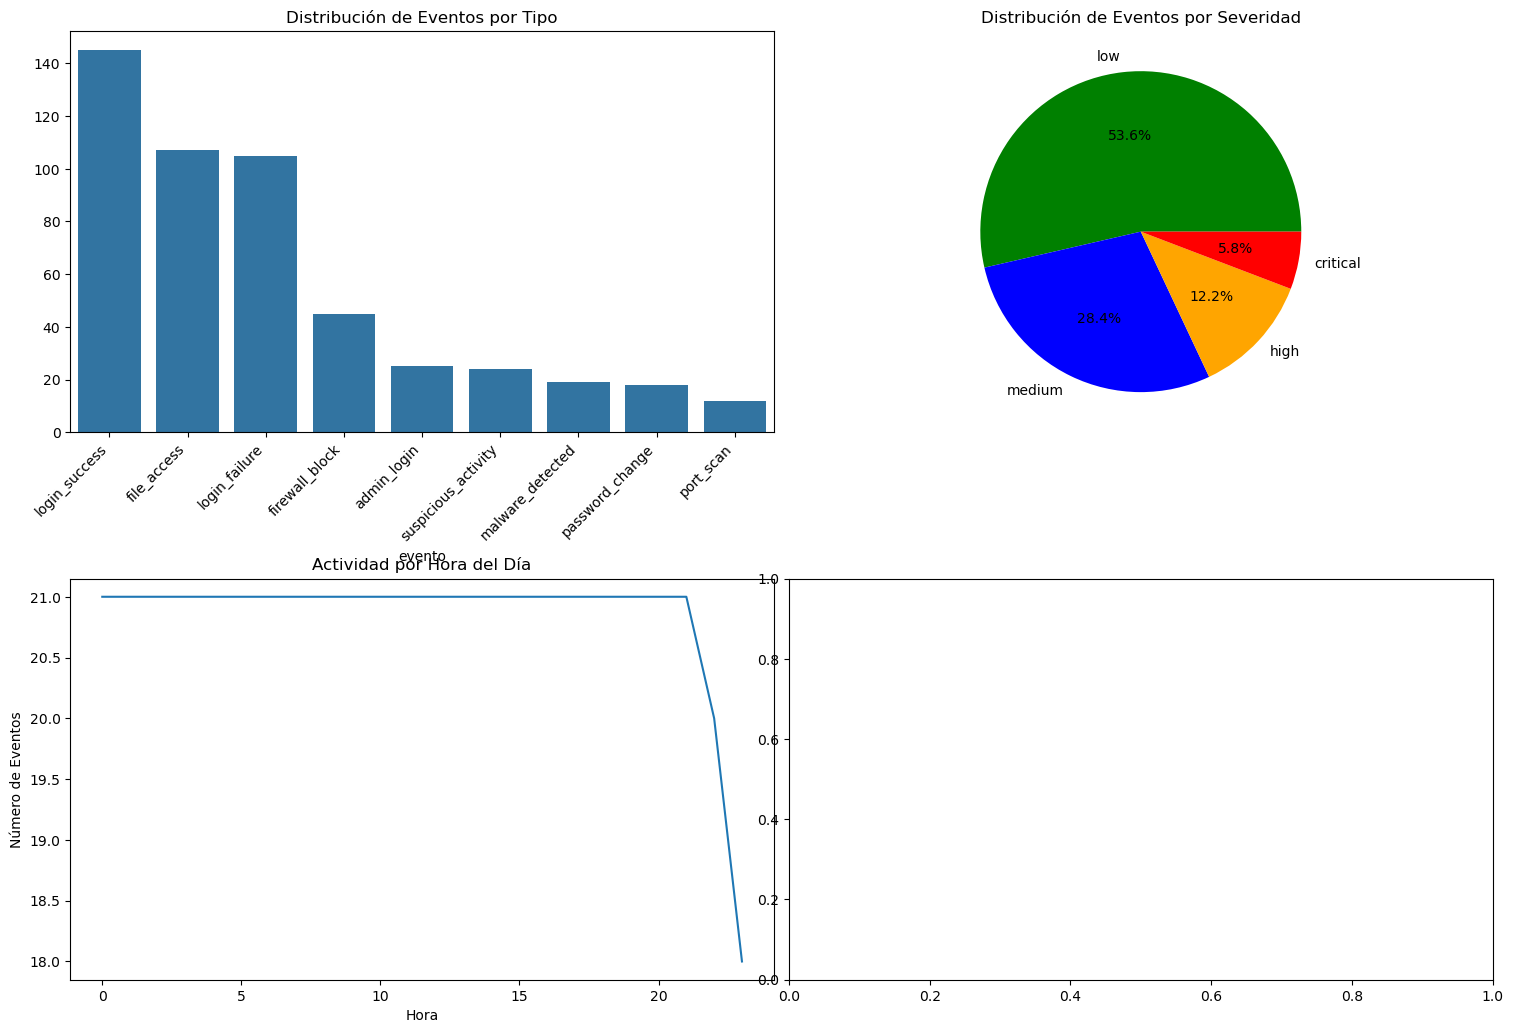

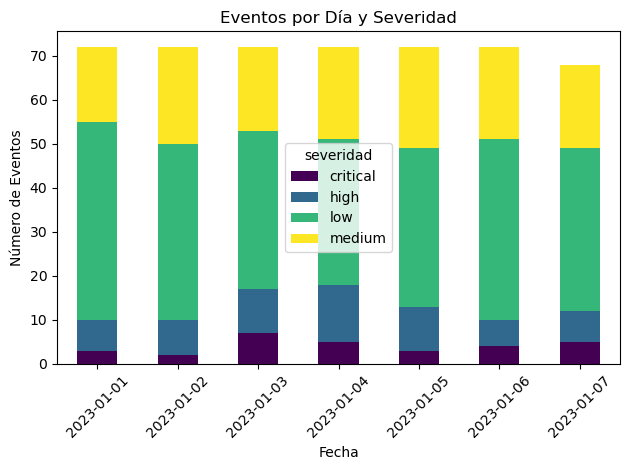

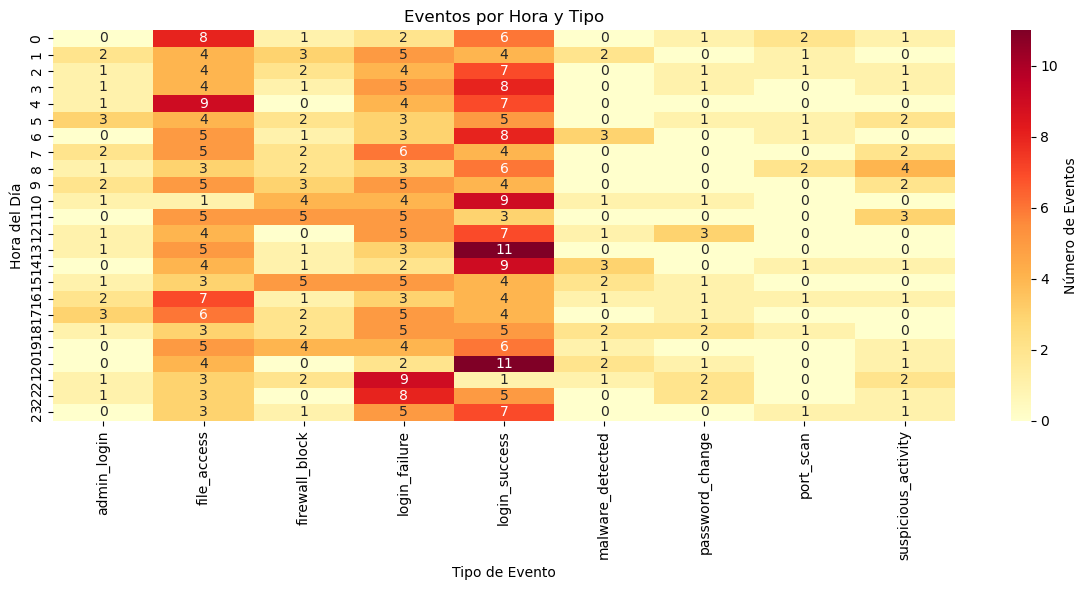

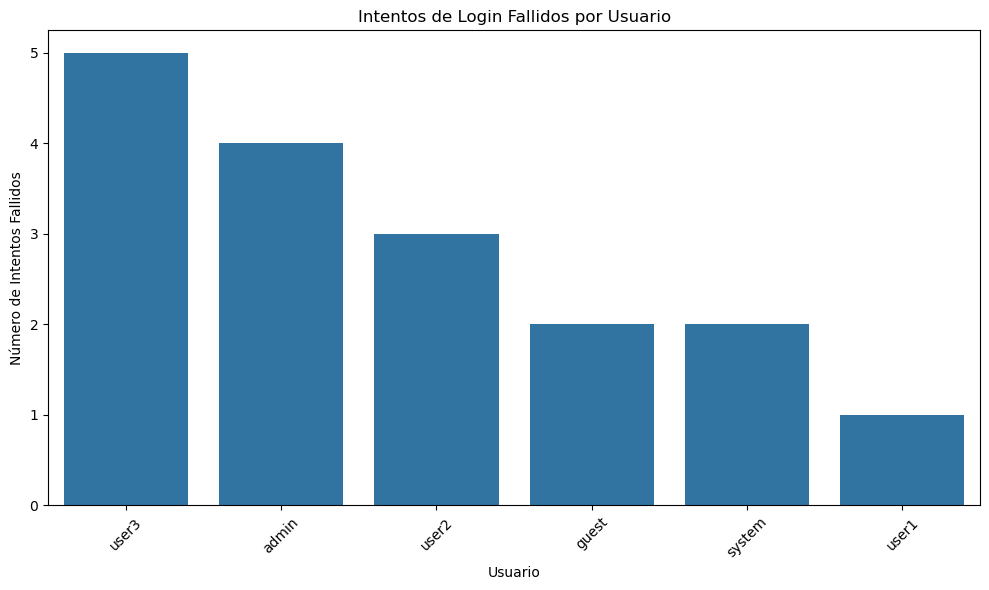

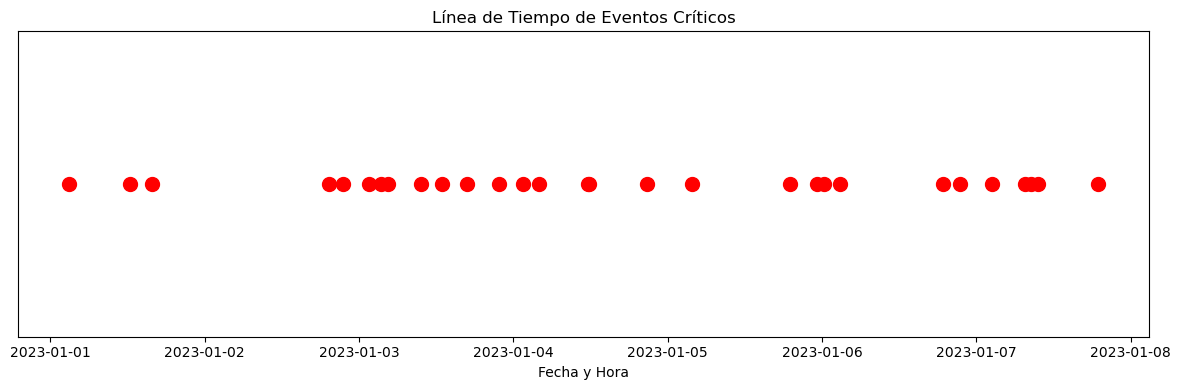

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Usaremos los datos generados en el ejemplo anterior
# Para simplificar, recreamos un conjunto similar pero más pequeño

# Generar 500 registros de logs simulados
np.random.seed(42)

# Lista de eventos de seguridad
eventos = ['login_success', 'login_failure', 'file_access', 'admin_login', 
           'password_change', 'firewall_block', 'suspicious_activity', 
           'malware_detected', 'port_scan']

# Generar timestamps para una semana
fechas = pd.date_range(start='2023-01-01', periods=7)
timestamps = []
for fecha in fechas:
    for hora in range(24):
        for _ in range(3):  # 3 eventos por hora aprox
            timestamps.append(fecha + pd.Timedelta(hours=hora) + 
                             pd.Timedelta(minutes=np.random.randint(60)))

# Ajustar al número de registros deseados
timestamps = timestamps[:500]

# Generar IPs aleatorias
def random_ip():
    return f"{np.random.randint(1, 256)}.{np.random.randint(1, 256)}.{np.random.randint(1, 256)}.{np.random.randint(1, 256)}"

# Usuarios del sistema
usuarios = ['admin', 'user1', 'user2', 'user3', 'system', 'guest', None]

# Generar datos simulados
data = {
    'timestamp': timestamps,
    'ip_origen': [random_ip() for _ in range(500)],
    'evento': np.random.choice(eventos, 500, p=[0.3, 0.2, 0.2, 0.05, 0.05, 0.08, 0.07, 0.03, 0.02]),
    'usuario': np.random.choice(usuarios, 500, p=[0.1, 0.2, 0.2, 0.2, 0.1, 0.1, 0.1]),
    'severidad': np.random.choice(['low', 'medium', 'high', 'critical'], 500, p=[0.5, 0.3, 0.15, 0.05]),
    'exitoso': np.random.choice([True, False], 500, p=[0.8, 0.2]),
}

# Crear DataFrame
logs_df = pd.DataFrame(data)

# Configurar timestamp como índice
logs_df['timestamp'] = pd.to_datetime(logs_df['timestamp'])
logs_df = logs_df.sort_values('timestamp')

# Ahora creamos las visualizaciones
plt.figure(figsize=(15, 10))

# 1. Distribución de eventos por tipo
plt.subplot(2, 2, 1)
eventos_count = logs_df['evento'].value_counts()
sns.barplot(x=eventos_count.index, y=eventos_count.values)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Eventos por Tipo')
plt.tight_layout()

# 2. Distribución de eventos por severidad
plt.subplot(2, 2, 2)
severidad_count = logs_df['severidad'].value_counts()
colors = {'low': 'green', 'medium': 'blue', 'high': 'orange', 'critical': 'red'}
plt.pie(severidad_count, labels=severidad_count.index, autopct='%1.1f%%',
        colors=[colors[sev] for sev in severidad_count.index])
plt.title('Distribución de Eventos por Severidad')

# 3. Actividad por hora del día
plt.subplot(2, 2, 3)
logs_df['hour'] = logs_df['timestamp'].dt.hour
hourly_count = logs_df.groupby('hour').size()
sns.lineplot(x=hourly_count.index, y=hourly_count.values)
plt.title('Actividad por Hora del Día')
plt.xlabel('Hora')
plt.ylabel('Número de Eventos')

# 4. Eventos por día y por severidad
plt.subplot(2, 2, 4)
logs_df['date'] = logs_df['timestamp'].dt.date
pivot_table = pd.crosstab(logs_df['date'], logs_df['severidad'])
pivot_table.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Eventos por Día y Severidad')
plt.xlabel('Fecha')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('security_dashboard.png')

# Crear gráfico de actividad sospechosa
plt.figure(figsize=(12, 6))

# 5. Mapa de calor de actividad por hora y tipo de evento
logs_df['hour'] = logs_df['timestamp'].dt.hour
heatmap_data = pd.crosstab(logs_df['hour'], logs_df['evento'])
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='d', cbar_kws={'label': 'Número de Eventos'})
plt.title('Eventos por Hora y Tipo')
plt.xlabel('Tipo de Evento')
plt.ylabel('Hora del Día')
plt.tight_layout()
plt.savefig('activity_heatmap.png')

# 6. Análisis de accesos fallidos por usuario
plt.figure(figsize=(10, 6))
failed_logins = logs_df[(logs_df['evento'] == 'login_failure') & (logs_df['exitoso'] == False)]
user_failures = failed_logins['usuario'].value_counts()
sns.barplot(x=user_failures.index.fillna('anónimo'), y=user_failures.values)
plt.title('Intentos de Login Fallidos por Usuario')
plt.xlabel('Usuario')
plt.ylabel('Número de Intentos Fallidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('failed_logins_by_user.png')

# 7. Línea de tiempo de eventos críticos
plt.figure(figsize=(12, 4))
critical_events = logs_df[logs_df['severidad'] == 'critical']
plt.scatter(critical_events['timestamp'], [1]*len(critical_events), c='red', s=100)
plt.yticks([])
plt.title('Línea de Tiempo de Eventos Críticos')
plt.xlabel('Fecha y Hora')
plt.tight_layout()
plt.savefig('critical_events_timeline.png')

print("Visualizaciones generadas correctamente. Revisa los archivos .png generados.")